In [31]:
from pathlib import Path
import sys
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from Data.dataset import MVTecDataset
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.models import wide_resnet50_2
import tqdm
data_path = project_root / "Data" / "mvtec" / "bottle"

In [2]:
torch.cuda.is_available()

True

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
class WideResNetFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()

        backbone = wide_resnet50_2(weights="DEFAULT")

        self.layer0 = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool
        )

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3

    def forward(self, x):
        x = self.layer0(x)
        x = self.layer1(x)

        feat2 = self.layer2(x)
        feat3 = self.layer3(feat2)

        return feat2, feat3

In [5]:
model = WideResNetFeatureExtractor()
model.eval()
print(model)

WideResNetFeatureExtractor(
  (layer0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
 

In [6]:
dataset = MVTecDataset(data_path, split="train", image_size=256)
dataloader = DataLoader(dataset, batch_size=4)

In [7]:
images = next(iter(dataloader))["image"]

In [10]:
feat2, feat3 = model(images)

In [11]:
print("feat2 shape:", feat2.shape)
print("feat3 shape:", feat3.shape)

feat2 shape: torch.Size([4, 512, 32, 32])
feat3 shape: torch.Size([4, 1024, 16, 16])


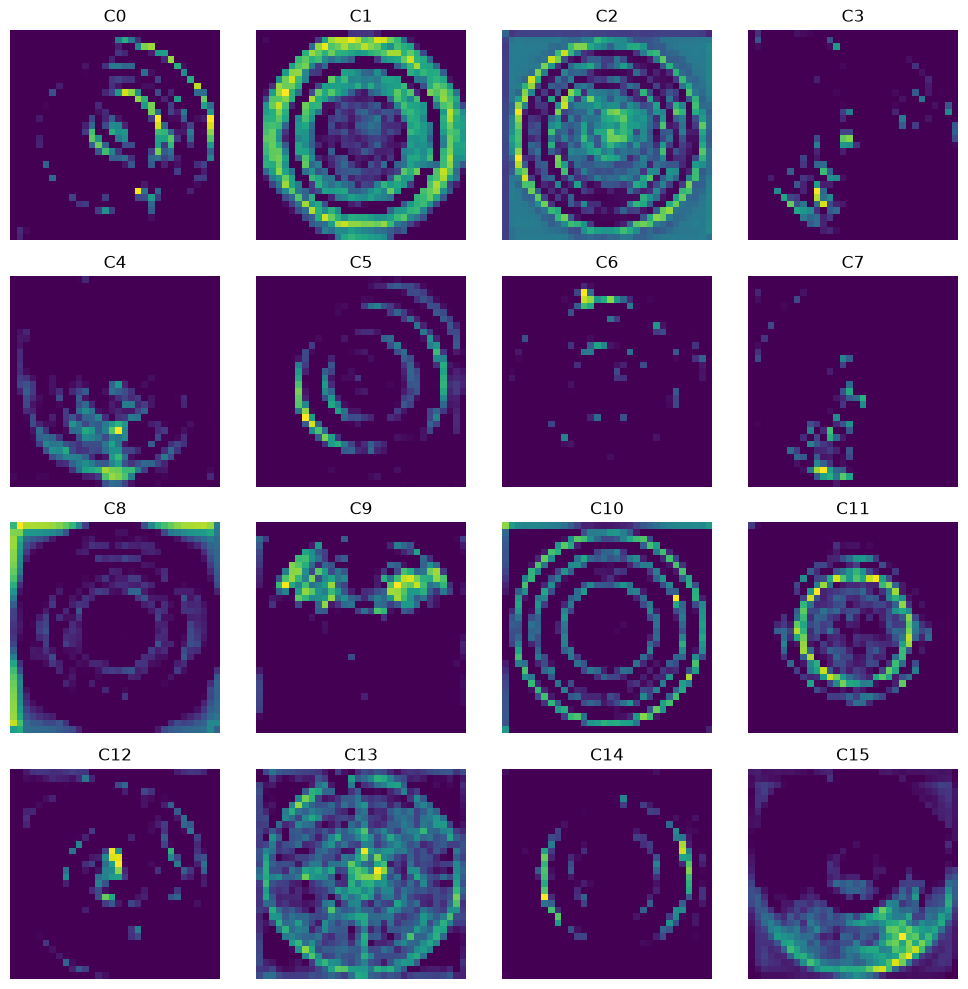

In [19]:
feature_map = feat2[0].detach()
fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    ax.imshow(feature_map[i], cmap="viridis")
    ax.axis("off")
    ax.set_title(f"C{i}")

plt.tight_layout()
plt.show()

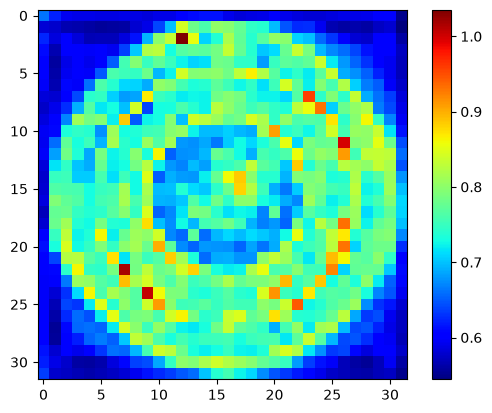

In [20]:
mean_map = feat2[0].detach().mean(dim=0)

plt.imshow(mean_map.cpu(), cmap="jet")
plt.colorbar()
plt.show()

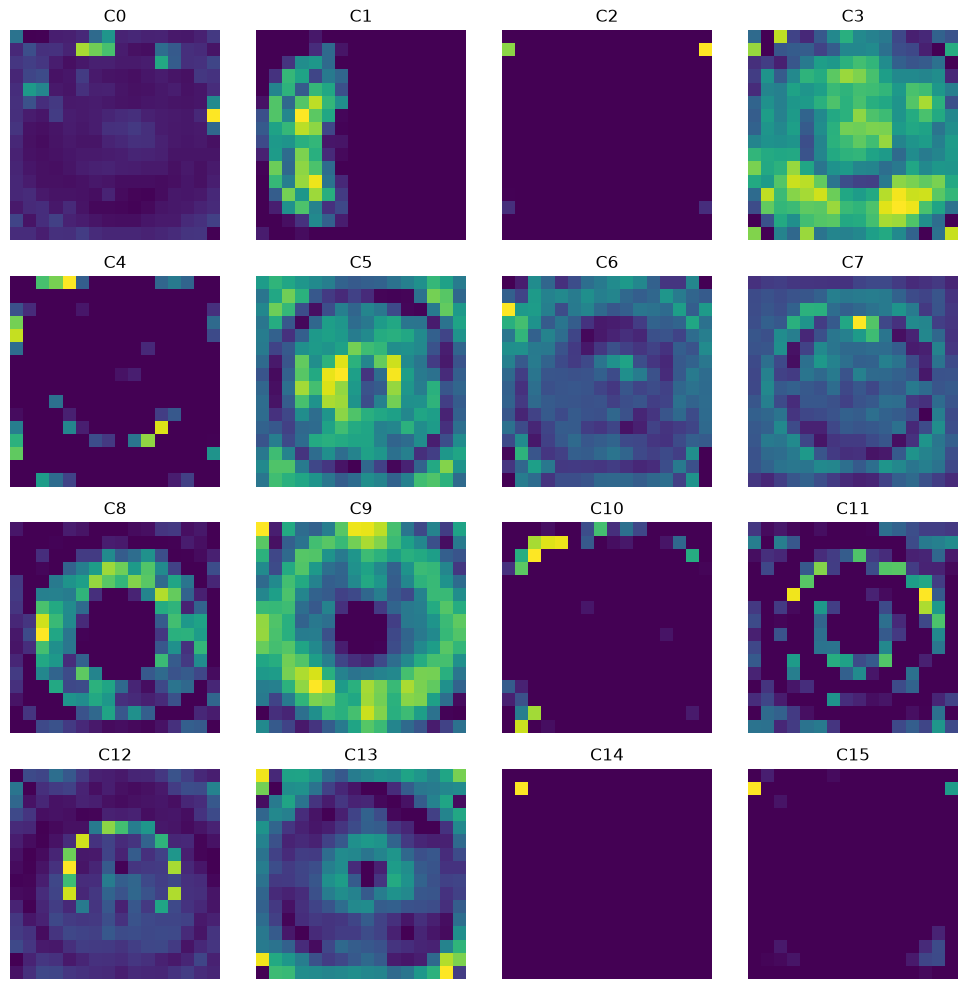

In [21]:
feature_map = feat3[0].detach()
fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    ax.imshow(feature_map[i], cmap="viridis")
    ax.axis("off")
    ax.set_title(f"C{i}")

plt.tight_layout()
plt.show()

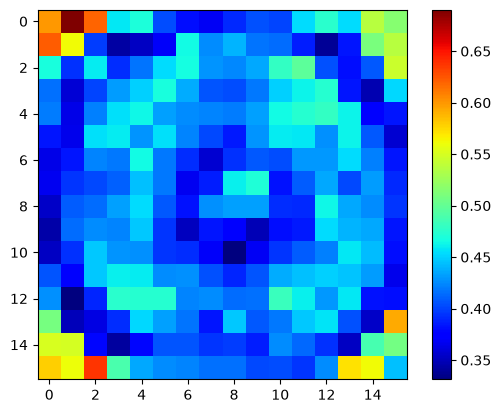

In [29]:
mean_map = feat3[0].detach().mean(dim=0)

plt.imshow(mean_map.cpu(), cmap="jet")
plt.colorbar()
plt.show()

In [30]:
print("feat2 shape:", feat2.shape)
print("feat3 shape:", feat3.shape)

feat2 shape: torch.Size([4, 512, 32, 32])
feat3 shape: torch.Size([4, 1024, 16, 16])


In [53]:
feat3_up = F.interpolate(feat3, size=feat2.shape[2:], mode="bilinear", align_corners=False)
print("feat3 upsampled shape:", feat3_up.shape)

feat3 upsampled shape: torch.Size([4, 1024, 32, 32])


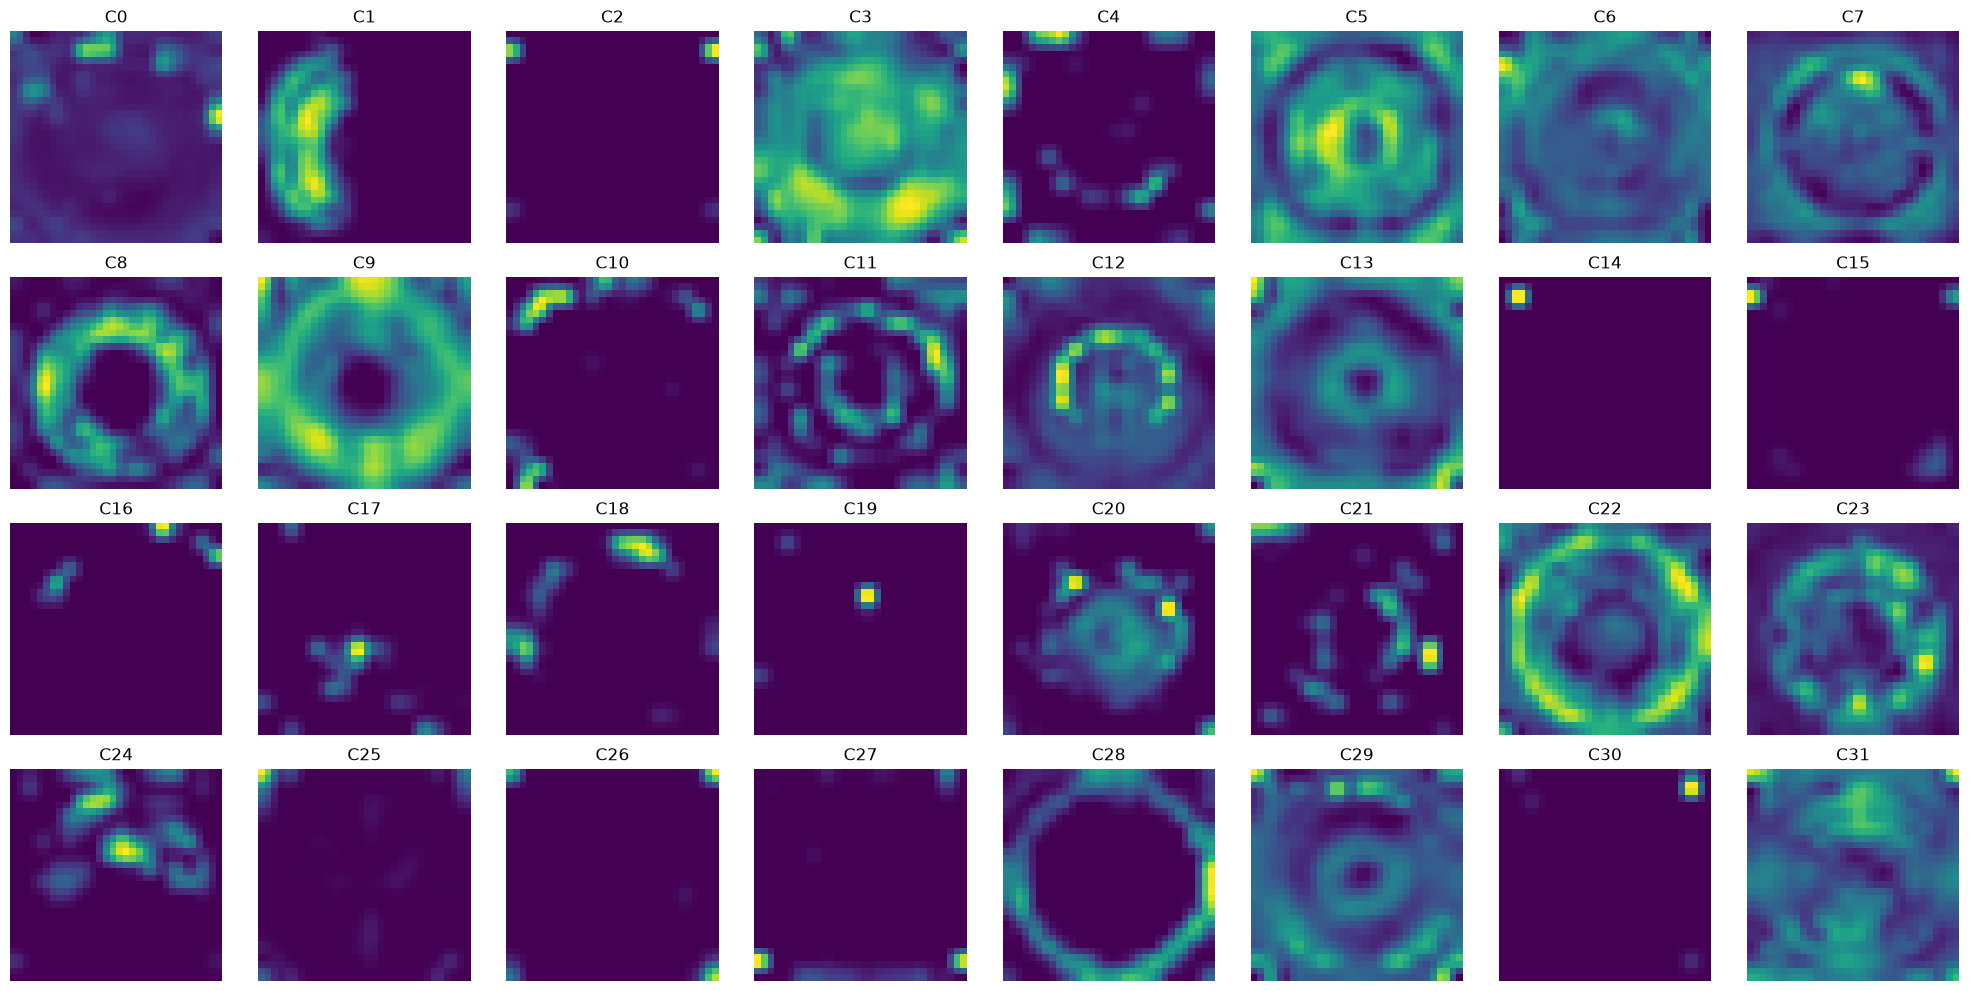

In [54]:
feature_map = feat3_up[0].detach()
fig, axes = plt.subplots(4, 8, figsize=(20, 10))

for i, ax in enumerate(axes.flat):
    ax.imshow(feature_map[i], cmap="viridis")
    ax.axis("off")
    ax.set_title(f"C{i}")

plt.tight_layout()
plt.show()

In [55]:
print(feat2.shape)
print(feat3_up.shape)

torch.Size([4, 512, 32, 32])
torch.Size([4, 1024, 32, 32])


In [57]:
combined = torch.cat([feat2, feat3_up],dim=1)
print("Combined feature shape:", combined.shape)

Combined feature shape: torch.Size([4, 1536, 32, 32])


In [58]:
print("Number of patches:", combined.shape[2] * combined.shape[3])
print("Feature dimension per patch:", combined.shape[1])

Number of patches: 1024
Feature dimension per patch: 1536


In [ ]:
embeddings = combined.permute(0, 2, 3, 1)
embeddings = embeddings.reshape(combined.shape[0],-1,combined.shape[1]) 